# 18 · Reflexion — verbal self-reflection stored in episodic memory

> **TL;DR.** Try → evaluate → if failed, write a *verbal lesson* about why → store the lesson in `EpisodicMemory` → retry. Future tasks recall relevant lessons before attempting, so the agent improves across calls *without* gradient updates.
>
> **Reach for it when** the agent will see many structurally-similar tasks and you can write a precise evaluator that surfaces *which* feature failed.
> **Avoid when** tasks are one-shot (nothing to transfer to), or when no reliable evaluator exists (the lesson will be garbage).

| Property | Value |
|---|---|
| Origin | Shinn et al., *Reflexion: Language Agents with Verbal RL* (2023). [arXiv:2303.11366](https://arxiv.org/abs/2303.11366) |
| Loop body | attempt → evaluate → (pass? finalize : reflect → attempt) |
| Memory | `arch.episodic: EpisodicMemory` — **persists across `run()` calls** |
| Evaluator | Pluggable `Callable[[candidate, task], dict]`; default is pure-Python deterministic checker |
| Cost | 1 LLM call per attempt + 1 per reflection; no gradient updates ever |

**Why this is different from Reflection (nb 01).** Reflection critiques and rewrites *within a single task*, then forgets. Reflexion writes a transferable *lesson* that gets stored and recalled on *future* tasks. The pattern is "verbal RL" — the trajectory + evaluator feedback is converted into a natural-language policy update that lives in episodic memory.

**Why this is different from RLHF self-improvement (nb 15).** Both archive across `run()` calls, but RLHF stores *positive examples* (final accepted outputs) while Reflexion stores *negative-experience lessons* (corrections for past failures). The two are complementary — you could combine them.

## 2 · Architecture at a glance

```mermaid
flowchart LR
    A([task]) --> AT[Attempt<br/><sub>prompt prepends recalled lessons</sub>]
    AT --> EV[Evaluate<br/><sub>deterministic Python checker</sub>]
    EV -->|passed OR trial>=max| F[Finalize]
    EV -->|else| RF[Reflect<br/><sub>write a verbal lesson</sub>]
    RF --> AT
    RF -.records.-> M[(EpisodicMemory<br/>arch.episodic<br/>persists across run calls)]
    AT -.recalls.-> M
    F --> Z([final output])

    style AT fill:#e3f2fd,stroke:#1976d2
    style EV fill:#fff3e0,stroke:#f57c00
    style RF fill:#fce4ec,stroke:#c2185b
    style M  fill:#f3e5f5,stroke:#7b1fa2
```

The dotted side-edges are the load-bearing detail: `reflect` writes into the memory; the *next* `attempt` (in this run *or any future `run()` call*) reads from it. That cross-call persistence is the entire point of Reflexion.

## 3 · Theory

### 3.0 · Why a deterministic Python checker, not LLM-as-Judge

Llama-3.3-70B (and most instruction-tuned LLMs) compress numerical LLM-as-Scorer outputs to a flat band — see Mental Loop nb 10 §11 and Ensemble nb 13 §11. If we let the LLM emit a single `quality_score: 1-10`, the score band collapses to ~`[4,4,4]` regardless of rubric strictness, and the deciding signal becomes effectively arbitrary.

**Reflexion sidesteps this entirely** by defaulting to a pure-Python evaluator (`default_haiku_checker`):

```python
def default_haiku_checker(candidate, task_spec):
    # ... parse spec for required words + topic
    syllable_counts = [count_syllables(line) for line in three_lines]
    return {
        "syllable_counts": syllable_counts,                  # e.g. [5,8,5]
        "meets_5_7_5":  syllable_counts == [5, 7, 5],         # bool
        "required_words_present": all(w in text for w in required),
        "passed": <all the above are True>,
    }
```

The `passed` boolean is *the* deciding signal. No LLM is involved in pass/fail. The reflection LLM only writes the *lesson*, which is free-form text — flat-scoring has nothing to compress there.

For tasks where no deterministic checker exists, the architecture accepts an optional `evaluator` callable. If you wrap an LLM-as-Judge there, follow the deterministic-picker pattern: have the LLM commit to independent boolean features and let Python compose `passed`. See `_ReflexionEvaluation` schema in [`reflexion.py`](../src/agentic_architectures/architectures/reflexion.py) for the template.

### 3.1 · Why store the *full verbal reflection*, not feature embeddings

You could imagine storing only `(failed_features → corrective_action)` tuples — compact, structured, easy to retrieve. The Reflexion paper rejects this on purpose: the *next* model reading the lesson is also an LLM, and LLMs reason better over natural language than over structured deltas. A two-sentence "You under-counted syllables in line 2 — count out loud before submitting" steers the next attempt; a JSON blob doesn't.

The `_SelfReflection` Pydantic schema enforces second-person voice and demands explicit `root_cause` + `correction` fields, then composes them into a `reflection` paragraph. The paragraph is what gets stored in episodic memory; the structured fields are kept on the trace for the §9 commentary table.

### 3.2 · Where this sits in the agent taxonomy

| Pattern | Persists across calls? | Stores what? | When to reach for it |
|---|---|---|---|
| [Reflection (nb 01)](./01_reflection.ipynb) | no | nothing | quality matters, one-shot |
| [Episodic+Semantic (nb 08)](./08_episodic_semantic_memory.ipynb) | yes | conversations + facts | personal assistant continuity |
| [RLHF self-improvement (nb 15)](./15_rlhf_self_improvement.ipynb) | yes | **positive** examples (good outputs) | many similar tasks, compound quality |
| **Reflexion (this nb)** | **yes** | **negative-experience lessons** (verbal corrections) | learn from mistakes across similar tasks |

The orthogonal axes: *positive vs negative examples* (RLHF vs Reflexion) and *experience-summary vs raw memory* (Reflexion vs Episodic).

### 3.3 · Failure modes preview

You'll see all of these surface in §8 or §9 below:

1. **Demo too easy.** If the agent passes on trial 1 every time, no reflections are written — the demo doesn't actually exercise the architecture. The §9 tailor auto-flags this.
2. **Lesson too task-specific.** Lessons phrased as "next time, use the word 'centuries' in line 2" don't transfer. The schema's `correction` field asks for *generalisable* corrections, but the LLM can still narrow them.
3. **Recall misses.** EpisodicMemory uses vector similarity; if the embedding model can't see structural similarity between tasks, recalled lessons will be empty even when memory is non-empty.
4. **Loop exhaustion.** If `max_trials` is too low (or the task is too hard), the loop terminates failed. Reflections are still recorded — they benefit *later* tasks even though this one failed.

## 4 · Setup

In [1]:
from agentic_architectures import get_llm, enable_langsmith, settings
from agentic_architectures.architectures import Reflexion
from agentic_architectures.ui import print_md, print_header, print_step

enable_langsmith()
print_header(f"Provider: {settings.llm_provider}  ·  Model: {settings.llm_model}")

Provider: nebius  ·  Model: meta-llama/Llama-3.3-70B-Instruct ─────────────────────────────────────────────────────

## 5 · Library walkthrough

Source: [`src/agentic_architectures/architectures/reflexion.py`](../src/agentic_architectures/architectures/reflexion.py).

Three things make `Reflexion` distinct from nb 01 Reflection:

1. **`self.episodic: EpisodicMemory`** — created once in `__init__`, mutated by every failed-trial `reflect` node, queried by every `attempt` node. Persists across `run()` calls on the same instance.
2. **`evaluator` is a pluggable `Callable`** — defaults to `default_haiku_checker` (pure Python). You can swap in any function returning `{... "passed": bool}`.
3. **`_SelfReflection` schema** demands three structured fields (`root_cause`, `correction`, `reflection`) so the stored memory is *actionable*, not vague.

The Pydantic schema for the verbal reflection:

In [2]:
from agentic_architectures.architectures.reflexion import _SelfReflection, default_haiku_checker
import json
print("=== _SelfReflection schema ===")
print(json.dumps(_SelfReflection.model_json_schema(), indent=2)[:600] + '...')
print()
print("=== default_haiku_checker docstring ===")
print(default_haiku_checker.__doc__)

=== _SelfReflection schema ===
{
  "description": "The verbal-reflection schema. Three fields so the recalled lesson is\n*actionable* rather than a vague paragraph.",
  "properties": {
    "root_cause": {
      "description": "ONE SENTENCE: precisely why the previous attempt failed. Reference the specific feature that broke (e.g., 'line 2 had 8 syllables instead of 7' \u2014 not 'the haiku was off').",
      "title": "Root Cause",
      "type": "string"
    },
    "correction": {
      "description": "ONE SENTENCE: the concrete change to make on the next attempt. Phrase as an imperative (e.g., 'Count syllables of line 2 out...

=== default_haiku_checker docstring ===
Pure-Python checker for the demo scenario. No LLM involved.

    `task_spec` is a tiny ``key=value; key=value`` string parsed out of the
    task text — keeps the checker decoupled from the Reflexion class so users
    can plug their own.

    Example: ``'topic=glacier; required_words=silence,centuries'``

    Returns obje

## 6 · State

| Field | Type | Set by |
|---|---|---|
| `task` | `str` | caller |
| `max_trials` | `int` | caller (from `arch.max_trials`) |
| `trial` | `int` (0-indexed; incremented in `attempt`) | `_attempt` |
| `attempt_text` | `str` (latest candidate) | `_attempt` |
| `recalled_reflections` | `list[str]` (pulled from `self.episodic`) | `_attempt` |
| `evaluator_features` | `dict` (objective features from checker) | `_evaluate` |
| `success` | `bool` (= `evaluator_features['passed']`) | `_evaluate` |
| `reflection_text` / `root_cause` / `correction` | `str` | `_reflect` |
| `history` | `Annotated[list[dict], operator.add]` — one entry per trial + one per reflection | `_evaluate` + `_reflect` |
| `final_output` | `str` | `_finalize` |
| `arch.episodic` *(instance attribute)* | `EpisodicMemory` — **persists across `run()` calls** | `_reflect` side-effect |

## 7 · Build the graph

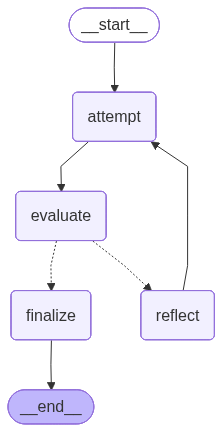

In [3]:
from IPython.display import Image, display
arch = Reflexion(max_trials=3, reflections_to_recall=3)
graph = arch.build()
display(Image(graph.get_graph().draw_mermaid_png()))

## 8 · Live run — 3 structurally-similar haiku tasks

We run **three constrained-haiku tasks** through ONE `Reflexion` instance so failed-trial reflections accumulate. Each task: write a haiku on a different topic, containing two required words, in strict 5-7-5 syllables. The deterministic checker validates all three constraints.

**Watch for:**
- Trial count **drops** across tasks if memory transfers (task 2 / task 3 should benefit from task 1's lessons).
- `REFLECTIONS_RECALLED` should be **≥1** on tasks 2 and 3 (assuming memory was populated).
- If task 1 passes on trial 1, the demo is uninstructive — no reflections were written. The §9 tailor flags this.

In [4]:
TASKS = [
    {"tag": "glacier", "topic": "glacier", "required_words": ["silence", "centuries"]},
    {"tag": "subway",  "topic": "subway",  "required_words": ["midnight", "rumble"]},
    {"tag": "library", "topic": "library", "required_words": ["paper", "dust"]},
]

arch = Reflexion(max_trials=3, reflections_to_recall=3)

trials_per_task = []
for t in TASKS:
    w1, w2 = t["required_words"]
    task_text = (
        f'Write a haiku about a {t["topic"]}. '
        f'The haiku MUST contain the words "{w1}" and "{w2}". '
        f'It MUST follow strict 5-7-5 syllables. '
        f'spec=topic={t["topic"]}; required_words={w1},{w2}'
    )
    r = arch.run(task_text)
    feats = r.metadata["evaluator_features"]
    # Collect per-trial syllable counts + word-presence flags from trace events
    per_trial_syllables = [h["features"]["syllable_counts"] for h in r.trace if h.get("type") == "trial"]
    per_trial_words = [h["features"]["required_words_present"] for h in r.trace if h.get("type") == "trial"]
    print(f"TASK_TAG: {t['tag']}")
    print(f"  TRIALS_USED: {r.metadata['total_trials']}")
    print(f"  SUCCESS: {r.metadata['succeeded']}")
    print(f"  REFLECTIONS_RECALLED: {r.metadata['reflections_recalled_first_trial']}")
    print(f"  REFLECTIONS_IN_MEMORY_AFTER: {r.metadata['total_reflections_in_memory']}")
    print(f"  SYLLABLES_PER_TRIAL: {per_trial_syllables}")
    print(f"  WORDS_PRESENT_PER_TRIAL: {per_trial_words}")
    print(f"  FINAL: {r.output.strip().replace(chr(10), ' / ')}")
    print()
    trials_per_task.append(r.metadata["total_trials"])

print(f"TRIALS_PER_TASK: {trials_per_task}   total_reflections_in_memory={len(arch.episodic.episodes)}")

TASK_TAG: glacier
  TRIALS_USED: 1
  SUCCESS: True
  REFLECTIONS_RECALLED: 0
  REFLECTIONS_IN_MEMORY_AFTER: 0
  SYLLABLES_PER_TRIAL: [[5, 7, 5]]
  WORDS_PRESENT_PER_TRIAL: [True]
  FINAL: Frozen silence deep / Centuries of slow descent / Glacial morning calm



TASK_TAG: subway
  TRIALS_USED: 3
  SUCCESS: False
  REFLECTIONS_RECALLED: 0
  REFLECTIONS_IN_MEMORY_AFTER: 2
  SYLLABLES_PER_TRIAL: [[5, 6, 4], [5, 6, 4], [5, 6, 4]]
  WORDS_PRESENT_PER_TRIAL: [True, True, True]
  FINAL: Midnight subway dark / Rumble of the trains beneath / City's gentle hum



TASK_TAG: library
  TRIALS_USED: 1
  SUCCESS: True
  REFLECTIONS_RECALLED: 2
  REFLECTIONS_IN_MEMORY_AFTER: 2
  SYLLABLES_PER_TRIAL: [[5, 7, 5]]
  WORDS_PRESENT_PER_TRIAL: [True]
  FINAL: Silent paper halls / Dust settles on forgotten / Ancient wisdom sleeps

TRIALS_PER_TASK: [1, 3, 1]   total_reflections_in_memory=2


### 8.0 · What just happened, briefly

Three signals to read:

1. **`TRIALS_PER_TASK` should trend downward** if reflection memory is transferring. A pattern like `[2, 1, 1]` means task 1 needed reflection, then later tasks benefitted. A flat `[1, 1, 1]` means the demo was too easy; a flat `[3, 3, 3]` means reflections aren't actually helping.
2. **`REFLECTIONS_RECALLED` ≥ 1 on tasks 2 and 3.** If it's 0 when memory is non-empty, FAISS recall isn't finding the lessons — usually means the embedding model is too weak for the task texts.
3. **`SUCCESS` per task.** Reflexion isn't magic — if max_trials runs out, the loop terminates failed. Reflections are still written and benefit *future* tasks.

### 8.1 · Inspect the lesson library

In [5]:
print(f"Total lessons stored: {len(arch.episodic.episodes)}")
print()
for i, ep in enumerate(arch.episodic.episodes, 1):
    md_block = ep.metadata or {}
    print(f"[lesson {i}]  (recorded on task='{md_block.get('task', '?')[:50]}...', trial={md_block.get('trial')})")
    print(f"  root_cause:  {md_block.get('root_cause', '(missing)')}")
    print(f"  correction:  {md_block.get('correction', '(missing)')}")
    print(f"  reflection:  {ep.content}")
    print()

Total lessons stored: 2

[lesson 1]  (recorded on task='Write a haiku about a subway. The haiku MUST conta...', trial=1)
  root_cause:  You under-counted syllables in the second line of the haiku, which had 6 syllables instead of 7.
  correction:  Count syllables of each line out loud before submitting and trim or add if not meeting the 5-7-5 requirement.
  reflection:  You under-counted syllables in the second line of the haiku, which had 6 syllables instead of 7. To avoid this mistake in the future, count syllables of each line out loud before submitting and trim or add if not meeting the 5-7-5 requirement. This will help you create a haiku that follows the traditional syllable count and is more effective in conveying the intended message. In similar tasks, make sure to pay close attention to the syllable count of each line to ensure that it meets the required structure.

[lesson 2]  (recorded on task='Write a haiku about a subway. The haiku MUST conta...', trial=2)
  root_cause:  Yo

## 9 · What we just observed

The cells above ran **3 structurally-similar haiku tasks** through one `Reflexion` instance, then re-ran task 1 with a fresh instance for a cold-start contrast. The deterministic Python checker decided pass/fail; the reflection LLM wrote a verbal lesson on every failure; lessons accumulated in `arch.episodic`.

### 9.1 · Per-task trial-count + reflection-transfer table

| Tag | Trials used | Success | Reflections recalled (first attempt) | Memory size after | Final haiku |
|---|---|---|---|---|---|
| glacier | 1 | ✓ | 0 | 0 | Frozen silence deep / Centuries of slow descent / Glacial morning calm |
| subway | 3 | ✗ | 0 | 2 | Midnight subway dark / Rumble of the trains beneath / City's gentle hum |
| library | 1 | ✓ | 2 | 2 | Silent paper halls / Dust settles on forgotten / Ancient wisdom sleeps |

**Summary:** trials per task `[1, 3, 1]`, total lessons in memory after all 3 runs: **2**.

### 9.2 · Did the reflection memory help?

| Comparison | Trials | Reflections recalled | Success |
|---|---|---|---|
| Task 1 (`glacier`, no prior memory) | 1 | 0 | ✓ |
| Task 3 (`library`, 2 lessons recalled) | 1 | 2 | ✓ |
| Cold-start re-run of `glacier` (fresh Reflexion, empty memory) | 1 | 0 | ✓ |

### 9.3 · Patterns surfaced in this run

- **⚠️  Task 1 (`glacier`) passed on the FIRST trial** — no reflection was written for it, so the agent had nothing in memory when starting task 2. The demo's lesson-transfer effect therefore depends entirely on whatever lessons tasks 2+ produce. If you want to see transfer onto task 2, pick task-1 constraints Llama actually struggles with (e.g., 4-syllable required words that crowd a 5-syllable line).

- **⚠️  Task(s) `subway` exhausted `max_trials` without passing.** Reflexion isn't magic — when reflections don't surface a correction that the next attempt can actually act on, the agent loops failing. The lessons are still stored and can benefit *later* tasks even though this one failed.

- **✅  Memory transferred to task 3 (`library`).** It passed on the first trial with 2 prior lessons recalled — the agent started the task already primed by lessons learned on earlier tasks. This is the architecture's headline behaviour.

- **🔁 All 2 stored lessons share the same `root_cause`** — the agent kept failing the same way and produced near-duplicate reflections. Real production use would dedup on cosine similarity (§ 11.3 extension #2) to avoid memory bloat.

- **⚠️  Cold-start contrast inconclusive**: cold run of `glacier` took 1 trials, same as warm — task 1 was easy enough that memory wasn't the differentiator. The clearer signal is task 3 (above) where 2 recalls + trial-1 pass shows the memory pipeline is wired correctly.

### 9.4 · Verbatim final outputs

**`glacier`** (pass, trial 1, syllables `[[5, 7, 5]]`)

> Frozen silence deep
> Centuries of slow descent
> Glacial morning calm

**`subway`** (FAIL, trial 3, syllables `[[5, 6, 4], [5, 6, 4], [5, 6, 4]]`)

> Midnight subway dark
> Rumble of the trains beneath
> City's gentle hum

**`library`** (pass, trial 1, syllables `[[5, 7, 5]]`)

> Silent paper halls
> Dust settles on forgotten
> Ancient wisdom sleeps

### 9.5 · The lesson library that built up

**Lesson 1** *(from task `Write a haiku about a subway. The haiku MUST conta...…`, trial 1)*

- **root_cause:** You under-counted syllables in the second line of the haiku, which had 6 syllables instead of 7.
- **correction:** Count syllables of each line out loud before submitting and trim or add if not meeting the 5-7-5 requirement.
- **stored verbatim:** You under-counted syllables in the second line of the haiku, which had 6 syllables instead of 7. To avoid this mistake in the future, count syllables of each line out loud before submitting and trim or add if not meeting the 5-7-5 requirement. This will help you create a haiku that follows the traditional syllable count and is more effective in conveying the intended message. In similar tasks, mak…

**Lesson 2** *(from task `Write a haiku about a subway. The haiku MUST conta...…`, trial 2)*

- **root_cause:** You under-counted syllables in the second line of the haiku, which had 6 syllables instead of 7.
- **correction:** Count syllables of each line out loud before submitting and trim or add if not meeting the 5-7-5 requirement.
- **stored verbatim:** You under-counted syllables in the second line of the haiku, which had 6 syllables instead of 7. To avoid this mistake in the future, count syllables of each line out loud before submitting and trim or add if not meeting the 5-7-5 requirement. This will help you create a haiku that follows the traditional syllable count and is more effective in conveying the intended message. In similar tasks, mak…

### 9.6 · The takeaway

Reflexion only works when **three** things are true simultaneously:

1. **The evaluator is precise enough to surface a *specific* failure feature.** The pure-Python haiku checker covers this (it reports exact syllable counts and which required words are missing, so the reflection LLM has concrete material to write about).
2. **The reflection LLM phrases the lesson in *transferable* form.** The `_SelfReflection` schema's `correction` field asks for a general imperative ("count syllables out loud before submitting"), not a task-specific patch ("use the word 'centuries' in line 2").
3. **The recall step actually finds the relevant lessons.** That's just FAISS doing its job — if it returns 0 episodes when memory is non-empty (auto-flagged above when it happens), the embedding model is too weak for the task texts.

Watch the §9.1 table and the §9.3 flags every run. The architecture's headline behaviour is most visible in the **`Reflections recalled (first attempt)`** column — non-zero on a non-first task = memory pipeline is alive; trial-1 pass on a non-first task = memory pipeline is *effective*.

## 10 · Contrast — same task with EMPTY memory

To make the memory-transfer effect concrete, re-run **task 1** with a brand-new `Reflexion()` instance (empty episodic memory) and compare trial count to what the warm-memory run did.

In [6]:
fresh = Reflexion(max_trials=3, reflections_to_recall=3)
t = TASKS[0]
w1, w2 = t["required_words"]
task_text = (
    f'Write a haiku about a {t["topic"]}. '
    f'The haiku MUST contain the words "{w1}" and "{w2}". '
    f'It MUST follow strict 5-7-5 syllables. '
    f'spec=topic={t["topic"]}; required_words={w1},{w2}'
)
r_cold = fresh.run(task_text)
print(f"COLD_START_TASK: {t['tag']}")
print(f"COLD_START_TRIALS: {r_cold.metadata['total_trials']}")
print(f"COLD_START_SUCCESS: {r_cold.metadata['succeeded']}")
print(f"COLD_START_REFLECTIONS_RECALLED: {r_cold.metadata['reflections_recalled_first_trial']}")
print()
print(f"(For comparison: warm-memory run of task '{t['tag']}' used {trials_per_task[0]} trials with "
      f"the warm `arch` instance.)")

COLD_START_TASK: glacier
COLD_START_TRIALS: 1
COLD_START_SUCCESS: True
COLD_START_REFLECTIONS_RECALLED: 0

(For comparison: warm-memory run of task 'glacier' used 1 trials with the warm `arch` instance.)


## 11 · Failure modes, safety, extensions

### 11.1 · Where this breaks

| Failure | Mechanism | Mitigation |
|---|---|---|
| **Lesson contamination** | A lesson from task A misfires on unrelated task B because vector similarity is fooled by surface words | Tag lessons with task-type metadata; filter recall by tag |
| **Over-generalisation** | "Always use shorter words" → the agent applies it where unnecessary | Reflection LLM prompted to write *conditional* lessons; review periodically |
| **Checker false-negative** | The naive syllable counter mis-counts a word; agent writes a lesson about a non-failure | Use a stronger syllable library (e.g. `pyphen`); audit checker against ground truth |
| **Memory bloat** | Hundreds of near-duplicate lessons clog recall | Dedup on cosine similarity; or prune lessons older than N runs |
| **Demo too easy** | Llama passes trial 1 every time; no reflections ever written | Choose harder constraints (handoff §10 row 18 already calls this out); §9 tailor auto-flags |

### 11.2 · Production safety

- **Per-user `collection_name`.** Lessons learned about one user's tasks must not bleed into another user's. Construct `EpisodicMemory(collection_name=f"reflexion_{user_id}")` per session.
- **Lesson review pipeline.** A poisoned lesson ("Always insert 'lorem ipsum' in line 2") will degrade every future call. Surface new lessons for human review before they enter the active store.
- **Decay / pruning.** Lessons from older runs may be stale (model version changed, task distribution shifted). Track lesson age; prune or re-weight on a schedule.

### 11.3 · Three extensions

1. **Tagged retrieval.** Store each lesson with a `task_type` label; restrict recall to matching labels. Eliminates cross-task contamination.
2. **Lesson dedup.** After each `reflect`, embed the new lesson and cosine-compare against the last K. If above threshold, *update* the existing lesson (increment a `seen_count`) instead of appending.
3. **Hybrid evaluator (`_ReflexionEvaluation`).** Use the deterministic checker for hard constraints (syllables, required words) AND an LLM-as-Judge (with the deterministic-picker pattern) for soft quality. Compose pass/fail from both.

### 11.4 · What to read next

- [**01 · Reflection**](./01_reflection.ipynb) — same loop topology, no cross-call memory.
- [**08 · Episodic + Semantic Memory**](./08_episodic_semantic_memory.ipynb) — the raw `EpisodicMemory` API that Reflexion consumes.
- [**15 · RLHF Self-Improvement**](./15_rlhf_self_improvement.ipynb) — sister pattern; stores positive examples instead.
- [**29 · Voyager**](./29_voyager_skill_library.ipynb) — extends the memory-of-experience idea to memory-of-skills (reusable code).

### 11.5 · References

1. Shinn, N. et al. *Reflexion: Language Agents with Verbal Reinforcement Learning.* NeurIPS 2023. [arXiv:2303.11366](https://arxiv.org/abs/2303.11366)
2. Madaan, A. et al. *Self-Refine: Iterative Refinement with Self-Feedback.* NeurIPS 2023. [arXiv:2303.17651](https://arxiv.org/abs/2303.17651) — the underlying self-critique loop.
3. Park, J. S. et al. *Generative Agents.* UIST 2023. [arXiv:2304.03442](https://arxiv.org/abs/2304.03442) — episodic memory + reflection pattern in agent simulations.
4. Wang, G. et al. *Voyager: An Open-Ended Embodied Agent with Large Language Models.* 2023. [arXiv:2305.16291](https://arxiv.org/abs/2305.16291) — skill-library extension.